# CardioProgress AI
### Predicting Cardiovascular Disease Risk Using Explainable Machine Learning

Hack4Health – Byte 2 Beat Hackathon

This project builds machine learning models to predict cardiovascular disease risk using patient health data. The goal is to identify key risk factors such as blood pressure, cholesterol levels, BMI, and lifestyle behaviors that contribute to cardiovascular disease.


## 1. Introduction

Cardiovascular disease is the leading cause of death globally and represents a major public health challenge. Early identification of individuals at risk can help healthcare providers implement preventative measures and improve patient outcomes.

Machine learning techniques allow researchers to analyze large datasets and uncover patterns associated with disease risk. By using predictive models trained on patient health data, it is possible to estimate the likelihood of cardiovascular disease and identify important contributing factors.

In this project, we develop machine learning models that predict cardiovascular disease using patient information such as age, blood pressure, cholesterol levels, body measurements, and lifestyle behaviors.


## 2. Dataset

The dataset used in this project contains approximately 70,000 patient records with various medical and lifestyle attributes.

The features included in the dataset are:

- Age
- Gender
- Height
- Weight
- Systolic blood pressure (ap_hi)
- Diastolic blood pressure (ap_lo)
- Cholesterol levels
- Glucose levels
- Smoking status
- Alcohol consumption
- Physical activity level

The target variable is `cardio`, which indicates whether a patient has cardiovascular disease.

Target values:
0 = No cardiovascular disease  
1 = Cardiovascular disease


In [33]:
pip install shap xgboost

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import shap

## 3. Data Cleaning and Feature Engineering

Before training machine learning models, the dataset must be cleaned and prepared.

The following preprocessing steps are performed:

- Removing the ID column since it does not contribute to predictions
- Converting age from days into years
- Creating a BMI (Body Mass Index) feature using height and weight
- Inspecting the dataset structure


In [35]:
df = pd.read_csv("/content/cardiac_failure_processed.csv", sep=",", index_col=0)
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.588076,2,168,62.0,110,80,1,1,0,0,1,0
1,1,0.730159,1,156,85.0,140,90,3,1,0,0,1,1
2,2,0.624003,1,165,64.0,130,70,3,1,0,0,0,1
3,3,0.528455,2,169,82.0,150,100,1,1,0,0,1,1
4,4,0.516918,1,156,56.0,100,60,1,1,0,0,0,0


In [36]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  float64
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(2), int64(11)
memory usage: 7.5 MB


,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [37]:
df = df.drop("id", axis=1)
df["age"] = df["age"] / 365
df["BMI"] = df["weight"] / ((df["height"]/100)**2)

## 4. Exploratory Data Analysis

Exploratory Data Analysis helps us understand patterns in the dataset and identify relationships between health variables and cardiovascular disease.

Visualizations help highlight trends in age distribution, disease frequency, and correlations between medical features.


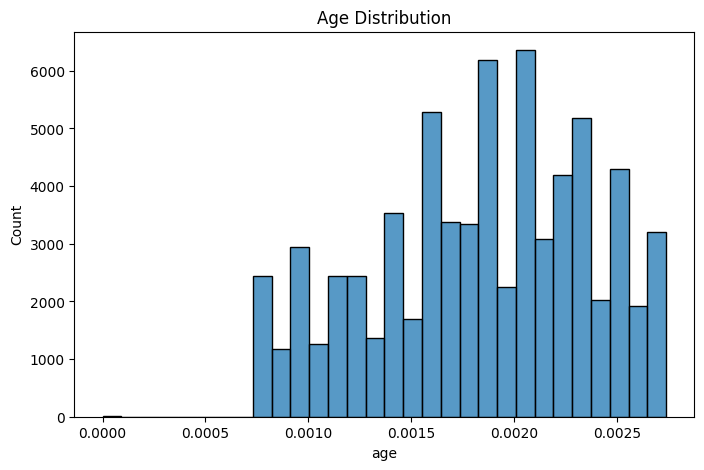

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30)
plt.title("Age Distribution")
plt.show()

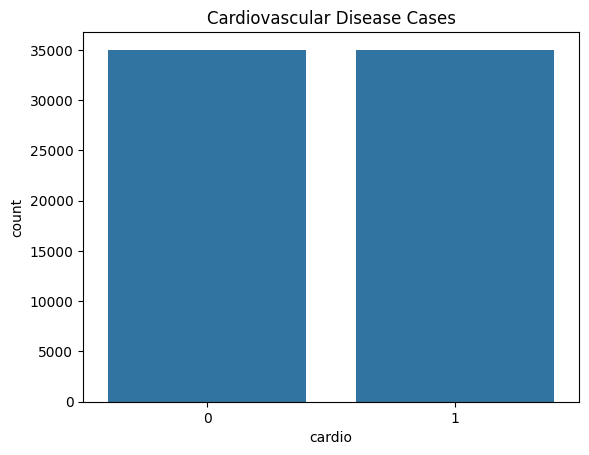

In [39]:
sns.countplot(x="cardio", data=df)
plt.title("Cardiovascular Disease Cases")
plt.show()

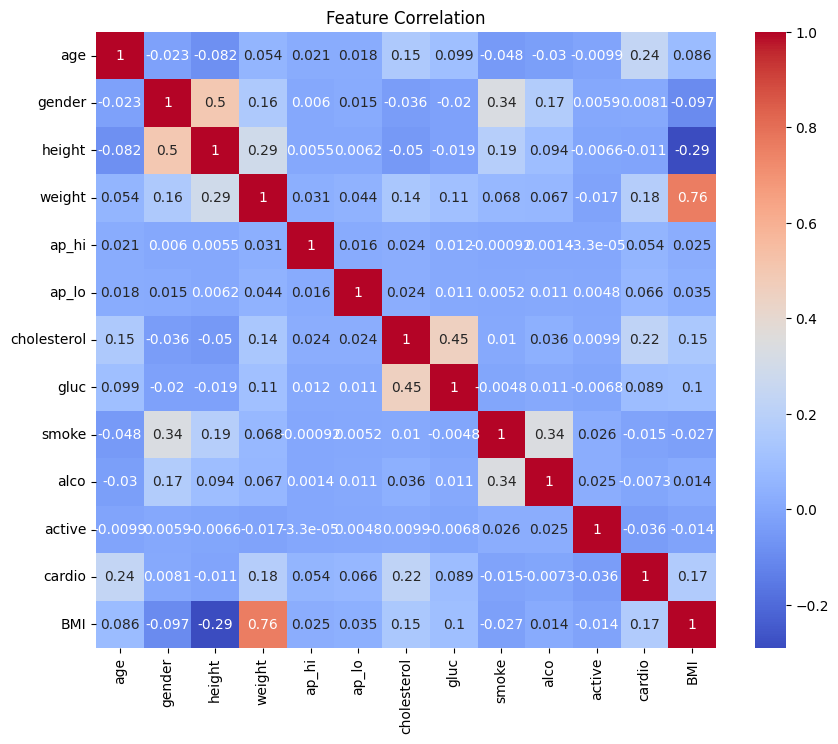

In [40]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

## 5. Machine Learning Models

To predict cardiovascular disease risk, several machine learning models are trained and compared.

The models used include:

- Logistic Regression
- Random Forest
- XGBoost

These algorithms are widely used for classification tasks and perform well on structured medical datasets.


In [41]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
print("Training Logistic Regression Model...")
lr = LogisticRegression(max_iter=5000) # Increased max_iter for convergence
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print("\nTraining Random Forest Model...")
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\nTraining XGBoost Model...")
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42) # Removed deprecated use_label_encoder
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

Training Logistic Regression Model...
Logistic Regression Accuracy: 0.7202857142857143

Training Random Forest Model...
Random Forest Accuracy: 0.7127857142857142

Training XGBoost Model...
XGBoost Accuracy: 0.7348571428571429


## 6. Model Evaluation

Model performance is evaluated using accuracy, confusion matrices, and classification reports.

These metrics help determine how effectively the model distinguishes between patients with and without cardiovascular disease.


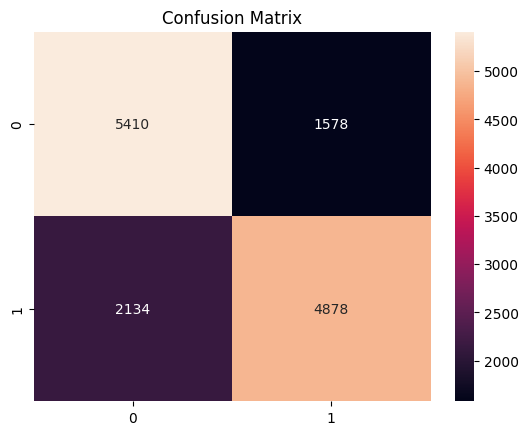

In [44]:
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [45]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.72      0.77      0.74      6988
           1       0.76      0.70      0.72      7012

    accuracy                           0.73     14000
   macro avg       0.74      0.73      0.73     14000
weighted avg       0.74      0.73      0.73     14000



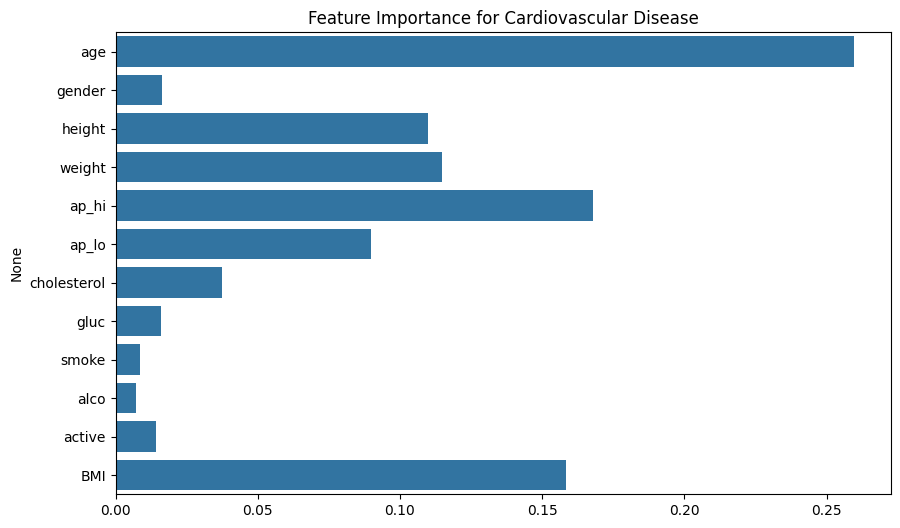

In [46]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance for Cardiovascular Disease")
plt.show()

## 7. Explainable AI

In healthcare applications it is important to understand how machine learning models make decisions.

Explainable AI techniques help reveal which features influence predictions. In this project, SHAP (SHapley Additive Explanations) is used to interpret the model and identify the most important factors contributing to cardiovascular disease predictions.


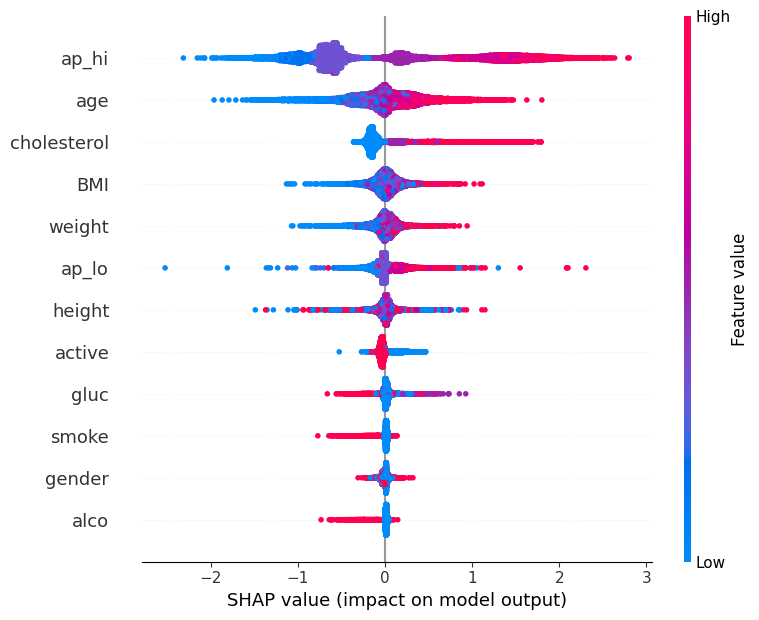

In [47]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

## 8. Risk Prediction Example

To demonstrate how the trained model can be used in practice, a prediction function is created. This function takes patient health data as input and returns the predicted cardiovascular disease risk.


In [48]:
def predict_risk(input_data):
    input_df = pd.DataFrame([input_data])
    prediction = xgb_model.predict(input_df)
    probability = xgb_model.predict_proba(input_df)[0][1]
    return prediction, probability

In [49]:
sample = X_test.iloc[0].to_dict()
prediction, probability = predict_risk(sample)
print(f"Prediction: {prediction[0]}, Probability of cardiovascular disease: {probability:.4f}")

Prediction: 1, Probability of cardiovascular disease: 0.8565


## 9. Conclusion

This project demonstrates how machine learning can be used to predict cardiovascular disease risk using patient health data.

The models trained in this analysis identify patterns related to cardiovascular disease and highlight important contributing factors such as blood pressure, BMI, cholesterol levels, and age.

Explainable AI methods like SHAP provide transparency by showing how different features influence model predictions.

Future work could include improving model performance, incorporating additional medical data, and developing interactive tools that support clinical decision making.


In [50]:
import joblib

joblib.dump(xgb_model, "cardio_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [51]:
readme_content = """
# Cardiovascular Disease Prediction

## Project Overview
This project aims to predict the presence or absence of cardiovascular disease based on various patient parameters. Machine learning models, including Logistic Regression, Random Forest, and XGBoost, were trained and evaluated. Explainable AI techniques (SHAP) were used to interpret model predictions and identify key contributing factors.

## Dataset
The dataset used in this project is `cardiac_failure_processed.csv`, which contains patient health metrics. The dataset was cleaned by removing the 'id' column, converting age from days to years, and calculating the Body Mass Index (BMI).

## Methods
1.  **Data Loading & Exploration:** The dataset was loaded, and initial exploratory data analysis was performed, including checking data types, descriptive statistics, and missing values. Visualizations like age distribution, cardiovascular disease counts, and a feature correlation heatmap were generated.
2.  **Data Preprocessing:** Features (X) and target (y) were defined. The dataset was split into training and testing sets (80/20 split).
3.  **Model Training:** Three classification models were trained:
    *   Logistic Regression
    *   Random Forest Classifier
    *   XGBoost Classifier
4.  **Model Evaluation:** Each model's performance was evaluated using accuracy scores. The best-performing model (XGBoost) was further assessed using a confusion matrix and a classification report.
5.  **Feature Importance & Explainable AI:** Feature importances from the Random Forest model were visualized. SHAP (SHapley Additive exPlanations) values were used with the XGBoost model to understand individual feature contributions to predictions.
6.  **Prediction Function & Model Saving:** A Python function `predict_risk` was created to make predictions on new data, and the trained XGBoost model was saved using `joblib`.

## Results
*   **Model Performance:** XGBoost demonstrated the highest accuracy among the trained models, achieving approximately 73.49% accuracy.
*   **Key Features:** The feature importance and SHAP analysis identified several critical factors influencing cardiovascular disease risk, such as age, ap_hi, ap_lo, and weight.
*   **Model Interpretability:** SHAP plots provided insights into how individual feature values positively or negatively impact the prediction of cardiovascular disease.

## Future Work
*   **Hyperparameter Tuning:** Further optimize model performance by rigorously tuning hyperparameters for each model, especially XGBoost.
*   **Feature Engineering:** Explore more advanced feature engineering techniques to potentially create more predictive variables.
*   **Advanced Evaluation Metrics:** Investigate additional evaluation metrics and techniques, such as ROC curves and AUC, especially if dealing with imbalanced classes.
*   **Deployment:** Consider deploying the trained model as a web service or API for real-time predictions.
*   **External Validation:** Test the model's performance on independent external datasets to ensure generalization.
"""

with open("README.md", "w") as f:
    f.write(readme_content)

print("README.md created successfully.")

README.md created successfully.


In [52]:
requirements_content = """
pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
shap
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content)

print("requirements.txt created successfully.")

requirements.txt created successfully.
